In [14]:
# load gaussian_annealing_naive_unweighted
import os
import pickle
import sys 

sys.path.append('.')
sys.path.append('..')
sys.path.append('../data')
# from src.plotting import create_all_plots

# print(os.listdir('../data'))

# data = pickle.load(open('polynomial/double_well/leapfrog/cd_unweighted.pkl', 'rb'))


In [15]:
# data['snapshots']['times']

/var/folders/v9/977m2z015_b794hqf_nk0q1r0000gn/T/ipykernel_31432/1571015540.py:28: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rho = rho / np.trapz(rho, x)  # Normalize


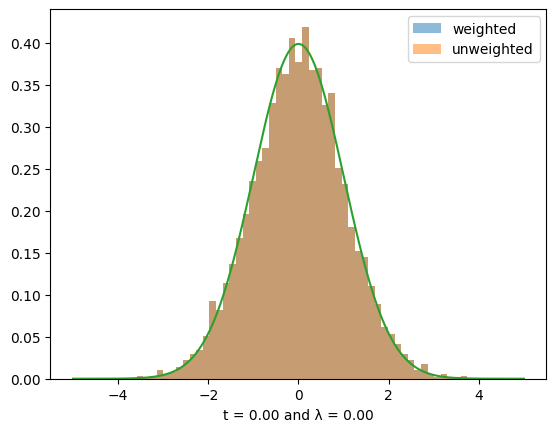

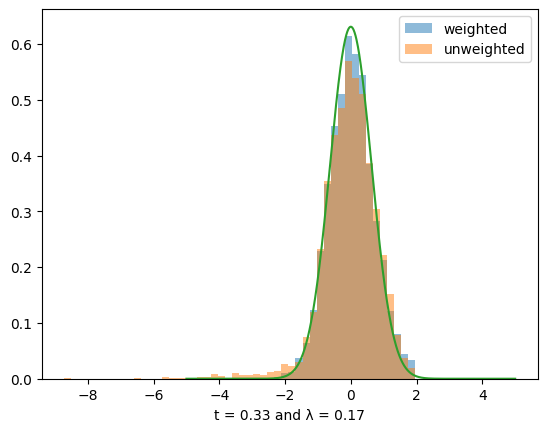

<Figure size 640x480 with 0 Axes>

In [73]:
# plot a gaussian with unit variance, 1D
import numpy as np
import matplotlib.pyplot as plt
from src.systems import SYSTEMS
import jax.numpy as jnp
# y is a normal pdf (scipy) with std 0.1
from scipy.stats import norm
from src.utils import normalize_log_weights
# y = norm.pdf(x, 0, 1/0.5)



def make_hist(file, system_name):
    data = pickle.load(open(file, 'rb'))

    x = np.linspace(-5, 5, 1000)


    times = data['snapshots']['times']
    lambdas = data['snapshots']['lam']
    for i in range(0,2):
        potential = SYSTEMS[system_name]['make_V'](lambdas[i])


        y = potential(x)
        # normalize y using trapezoid integration
        rho = np.array([np.exp(-potential(point)) for point in x])
        rho = rho / np.trapz(rho, x)  # Normalize

        # print(times[i])

        particles = data['snapshots']['particles']
        log_weights = data['snapshots']['weights'][i]
        weights = np.exp(normalize_log_weights(log_weights))
        
        all_weights = np.exp(data['snapshots']['weights'])
        all_weights = jnp.clip(all_weights, 0, 1).mean(axis=-1)
        # all_weights = all_weights.mean(axis=-1)
        
        
        plt.hist(particles[i][:,0], bins=50, weights=weights, density=True, alpha=0.5, label='weighted')
        plt.hist(particles[i][:,0], bins=50, density=True, alpha=0.5, label='unweighted')
        plt.plot(x, rho)
        plt.xlabel(f't = {times[i]:.2f} and λ = {lambdas[i]:.2f}')
        plt.legend()
        plt.show()
        plt.clf()


    # plt.plot(all_weights)
    # print(data)
    # plt.show()

system_name = 'gaussian_annealing'

# make_hist(file='naive/double_well/leapfrog/naive_weighted.pkl', i=0)
# make_hist(file='naive/double_well/leapfrog/naive_unweighted.pkl', i=20)
# make_hist(file='naive/double_well/leapfrog/naive_weighted.pkl', i=20)
# make_hist(file='polynomial/double_well/leapfrog/cd_unweighted.pkl', i=20)
# make_hist(file='polynomial/double_well/leapfrog/cd_weighted.pkl', i=20)
make_hist(file=f'polynomial/{system_name}/leapfrog/cd_weighted.pkl', system_name=system_name)
# make_hist(file='naive/double_well/leapfrog/cd_weighted.pkl', i=20)

(array([1.000e+00, 1.000e+00, 2.000e+00, 6.000e+00, 8.000e+00, 2.800e+01,
        4.000e+01, 7.700e+01, 1.380e+02, 2.340e+02, 3.480e+02, 5.340e+02,
        7.760e+02, 1.149e+03, 1.548e+03, 2.022e+03, 2.628e+03, 3.363e+03,
        4.117e+03, 4.674e+03, 5.564e+03, 6.109e+03, 6.756e+03, 6.947e+03,
        7.049e+03, 6.829e+03, 6.629e+03, 6.005e+03, 5.395e+03, 4.809e+03,
        3.979e+03, 3.170e+03, 2.580e+03, 1.932e+03, 1.469e+03, 1.067e+03,
        7.120e+02, 4.690e+02, 3.100e+02, 2.080e+02, 1.300e+02, 7.800e+01,
        4.900e+01, 3.000e+01, 1.700e+01, 7.000e+00, 2.000e+00, 3.000e+00,
        1.000e+00, 1.000e+00]),
 array([-4.32065105, -4.14380741, -3.96696353, -3.79011989, -3.61327624,
        -3.43643236, -3.25958872, -3.08274508, -2.90590143, -2.72905755,
        -2.55221391, -2.37537003, -2.19852638, -2.02168274, -1.8448391 ,
        -1.66799521, -1.49115157, -1.31430793, -1.13746405, -0.9606204 ,
        -0.78377676, -0.60693288, -0.43008924, -0.25324535, -0.07640171,
         0.

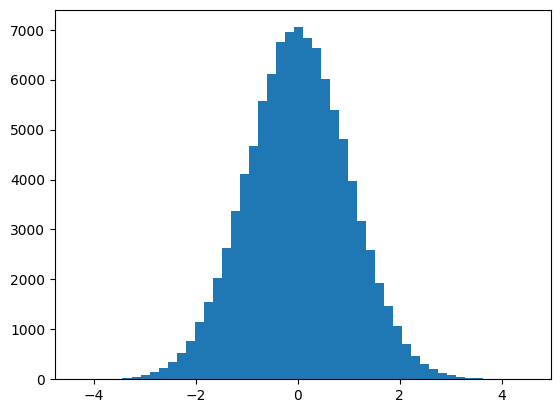

In [54]:
import jax
normals = jax.random.normal(jax.random.key(0), shape=(100000,))
plt.hist(normals, bins=50)